In [1]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

# ── Project root (notebook lives at repo root) ──────────────────────────────
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'SpaceEnv'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'GridNav'))

# ── Run to analyse ───────────────────────────────────────────────────────────
RUN_NAME = 'gridnav_iqn'   # change to match -info flag used during training
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)

In [2]:
# ── Load agents ──────────────────────────────────────────────────────────────
with open(os.path.join(RUN_DIR, f'{RUN_NAME}_agent.pkl'), 'rb') as f:
    agent = pickle.load(f)
print('Loaded main agent')

qd, qr = None, None
try:
    with open(os.path.join(RUN_DIR, f'{RUN_NAME}_Qd.pkl'), 'rb') as f:
        qd = pickle.load(f)
    with open(os.path.join(RUN_DIR, f'{RUN_NAME}_Qr.pkl'), 'rb') as f:
        qr = pickle.load(f)
    print('Loaded Qd and Qr networks')
except FileNotFoundError:
    print('Qd/Qr not found — re-train with the -ded flag to enable DeD analysis')

Loaded main agent
Loaded Qd and Qr networks


## 1. Ground truth regions

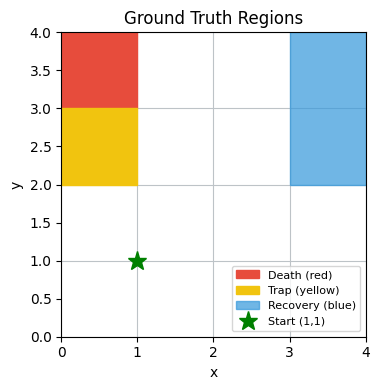

In [3]:
def plot_ground_truth(ax=None):
    """Draw the GridNav region layout on *ax* (creates one if None)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    else:
        fig = ax.figure

    ax.set_facecolor('white')

    # Region fills
    ax.add_patch(Rectangle((0, 3), 1, 1, color='#e74c3c', label='Death (red)',    zorder=2))
    ax.add_patch(Rectangle((0, 2), 1, 1, color='#f1c40f', label='Trap (yellow)', zorder=2))
    ax.add_patch(Rectangle((3, 2), 1, 2, color='#3498db', label='Recovery (blue)', alpha=0.7, zorder=2))

    # 1-unit grid lines
    for i in range(5):
        ax.axhline(i, color='#bdc3c7', lw=0.8, zorder=1)
        ax.axvline(i, color='#bdc3c7', lw=0.8, zorder=1)

    # Start position
    ax.plot(1, 1, 'g*', markersize=14, label='Start (1,1)', zorder=3)

    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Ground Truth Regions')
    ax.legend(loc='lower right', fontsize=8)
    return fig, ax

fig, ax = plot_ground_truth()
plt.tight_layout()
plt.show()

## 2. CVaR Q-value heatmaps over action space at state (1, 1)

For the fixed start state **(1, 1)** we sweep a regular grid of actions over the 4×4 action space:
1. Pass each (state, action) pair through the IQN to get `n_tau` quantile samples.
2. Compute the **lower CVaR** at level `eta`: average of the `eta`-fraction worst (lowest) quantiles.

This answers: *"from the start state, which actions look safest / most recoverable under worst-case quantile outcomes?"*

In [4]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
RESOLUTION = 50     # grid points per action axis (50×50 = 2500 actions)
N_TAU      = 32     # IQN quantile samples per (s,a) pair
ETA        = 0.25   # CVaR level (lower 25% of quantiles)
DEVICE     = 'cpu'
FIXED_STATE = [1.0, 1.0]  # state to evaluate

N_KEEP = max(1, int(ETA * N_TAU))
print(f'CVaR: keeping {N_KEEP}/{N_TAU} quantiles (eta={ETA})')
print(f'Fixed state: {FIXED_STATE}')


def compute_action_heatmap(ded_agent, state=FIXED_STATE, resolution=RESOLUTION,
                            n_tau=N_TAU, eta=ETA, device=DEVICE):
    """
    Sweep a grid of actions for a single fixed state and compute CVaR Q-values.

    Returns
    -------
    heatmap : (resolution, resolution) float32 array
        Row 0 = smallest ay, Row -1 = largest ay  (imshow origin='lower')
    axs, ays : 1-D arrays of action grid coordinates
    """
    axs = np.linspace(0.04, 3.96, resolution, dtype=np.float32)
    ays = np.linspace(0.04, 3.96, resolution, dtype=np.float32)
    AX, AY = np.meshgrid(axs, ays)                        # (R, R)
    actions = np.stack([AX.ravel(), AY.ravel()], axis=1)  # (R², 2)
    n_actions = len(actions)

    s = np.array([state], dtype=np.float32)               # (1, 2)
    states = np.tile(s, (n_actions, 1))                   # (R², 2)

    n_keep = max(1, int(eta * n_tau))
    network = ded_agent.qnetwork_local.to(device)
    network.eval()

    s_t = torch.from_numpy(states).to(device)
    a_t = torch.from_numpy(actions).to(device)

    with torch.no_grad():
        quantiles, _ = network.forward(s_t, a_t, num_tau=n_tau)
        # quantiles: (R², n_tau, 1)

    q = quantiles.squeeze(-1).cpu().numpy()   # (R², n_tau)
    q_sorted = np.sort(q, axis=1)             # ascending
    cvar = q_sorted[:, :n_keep].mean(axis=1) # (R²,)

    heatmap = cvar.reshape(resolution, resolution)  # (R_ay, R_ax)
    return heatmap, axs, ays


def plot_action_heatmap(heatmap, axs, ays, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    else:
        fig = ax.figure

    norm = TwoSlopeNorm(vmin=heatmap.min(), vcenter=0, vmax=max(heatmap.max(), 1e-6))
    im = ax.imshow(
        heatmap,
        origin='lower',
        extent=[axs[0], axs[-1], ays[0], ays[-1]],
        cmap='RdBu',
        norm=norm,
        aspect='equal',
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CVaR Q')
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_xlabel('action x')
    ax.set_ylabel('action y')
    ax.set_title(title)
    return fig, ax

CVaR: keeping 8/32 quantiles (eta=0.25)
Fixed state: [1.0, 1.0]


### 2a. Q_d (danger network) — action space at state (1, 1)
Actions leading toward danger should be **red (≈ −1)**; safe actions **white/blue**.

Computing Qd action heatmap at state [1.0, 1.0]...
  range: [-1.044, -0.001]


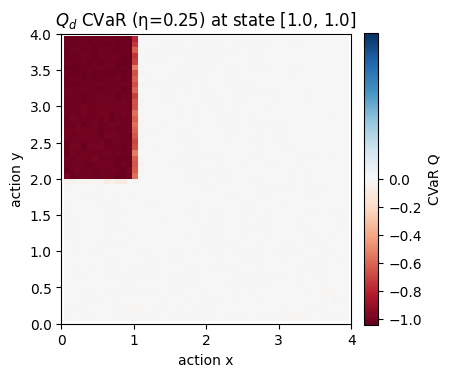

In [5]:
assert qd is not None, 'Qd not loaded — re-train with -ded flag'

print(f'Computing Qd action heatmap at state {FIXED_STATE}...')
heatmap_d, axs, ays = compute_action_heatmap(qd)
print(f'  range: [{heatmap_d.min():.3f}, {heatmap_d.max():.3f}]')

fig, ax = plot_action_heatmap(heatmap_d, axs, ays,
                               title=f'$Q_d$ CVaR (η={ETA}) at state {FIXED_STATE}')
plt.tight_layout()
plt.show()

### 2b. Q_r (recovery network) — action space at state (1, 1)
Actions that lead toward recovery should be **blue (≈ +1)**; others **white/red**.

Computing Qr action heatmap at state [1.0, 1.0]...
  range: [-0.037, 1.001]


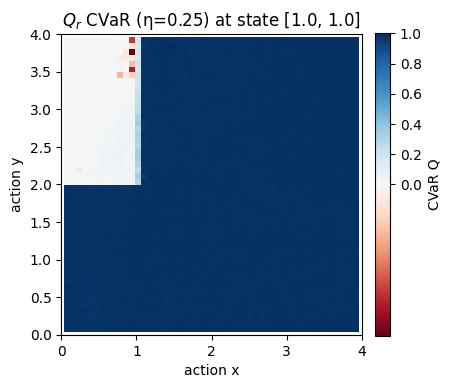

In [6]:
assert qr is not None, 'Qr not loaded — re-train with -ded flag'

print(f'Computing Qr action heatmap at state {FIXED_STATE}...')
heatmap_r, axs, ays = compute_action_heatmap(qr)
print(f'  range: [{heatmap_r.min():.3f}, {heatmap_r.max():.3f}]')

fig, ax = plot_action_heatmap(heatmap_r, axs, ays,
                               title=f'$Q_r$ CVaR (η={ETA}) at state {FIXED_STATE}')
plt.tight_layout()
plt.show()

## 3. Side-by-side summary

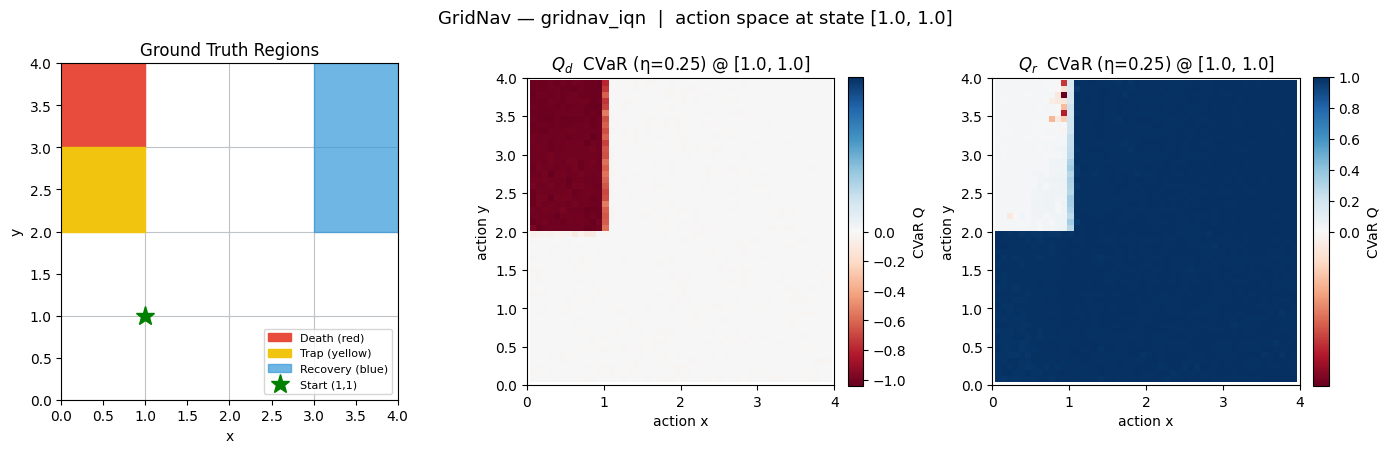

Saved to /home/jay/Uni/SafetyResearch/runs/gridnav_iqn/gridnav_ded_action_heatmaps.png


In [7]:
if qd is not None and qr is not None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    plot_ground_truth(ax=axes[0])
    plot_action_heatmap(heatmap_d, axs, ays,
                        title=f'$Q_d$  CVaR (η={ETA}) @ {FIXED_STATE}', ax=axes[1])
    plot_action_heatmap(heatmap_r, axs, ays,
                        title=f'$Q_r$  CVaR (η={ETA}) @ {FIXED_STATE}', ax=axes[2])

    fig.suptitle(f'GridNav — {RUN_NAME}  |  action space at state {FIXED_STATE}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'gridnav_ded_action_heatmaps.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', os.path.join(RUN_DIR, 'gridnav_ded_action_heatmaps.png'))